# 1. Statistics for selected nights

Take nights with data that has been fetched and get some stats including percentage in the galactic plane


# 2. Selecting nights to get data for

Get a list of JDs of full moons and new moons between 15-June-2023 and 15-June-2024, and adds three evenly spaced JDs between each full and new moon. Check how many ZTF alerts were generated on each of those nights, and if 0 alerts were generated (no observation), shift the JD in either direction by one night until it finds a night with observation. These jds are used with frigate to retrieve alerts.

In [3]:
from datetime import date as DATE
from datetime import datetime
import ephem
from typing import List, Tuple
import os
import glob
import subprocess
import sys
import yaml
from pathlib import Path
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
with open('../files/credentials.yaml', 'r') as file:
    credentials = yaml.safe_load(file)

kowalski_password = credentials['kowalski_password']

In [5]:
from penquins import Kowalski

instances = {
    "kowalski": {
        "name": "kowalski",
        "host": "kowalski.caltech.edu",
        "protocol": "https",
        "port": 443,
        "username": "knolan",
        "password": kowalski_password,
        "timeout": 6000
    },
    "gloria": {
        "name": "gloria",
        "host": "gloria.caltech.edu",
        "protocol": "https",
        "port": 443,
        "username": "knolan",
        "password": kowalski_password,
        "timeout": 6000
    }
}

kowalski = Kowalski(instances=instances)

# night stats

In [3]:
data_dir = Path('../../../data/frigate/23-24nights/')

# get night dates for labeling
file_paths = list(data_dir.glob('*.parquet'))
file_names = [parquet_file.name for parquet_file in file_paths]
nights = [name.split('_')[0] for name in file_names]
nights_mjd = night_names = [Time(night, format='jd').value - 2400000 for night in nights]
night_names = [Time(night, format='jd').to_value('iso', subfmt='date') for night in nights]

In [4]:
dfs = [pd.read_parquet(parquet_file) for parquet_file in file_paths]

In [ ]:
# check percentages in galactice plane

In [5]:
#use ra and dec to get galactic latitude

def add_galactic_latitude (df):
    ra = df['candidate.ra']    
    dec = df['candidate.dec']
    coords = SkyCoord(ra=ra.values * u.degree, dec=dec.values * u.degree, frame='icrs')
    galactic_coords = coords.galactic
    galactic_latitudes = galactic_coords.b.deg
    df['galactic_latitude'] = galactic_latitudes

add_latitudes = [add_galactic_latitude(df) for df in dfs]

In [6]:
percentage_10deg = [100 * len(df[df['galactic_latitude'].abs() < 10]) / len(df) for df in dfs]
print(percentage_10deg)

[32.7359819667512, 4.760672094883984, 0.0, 32.36722215561683, 40.39454141985986, 51.1550208990299, 0.0, 14.042030692264856, 14.654406861068207, 0.07646066230753006, 10.164195652486933, 33.38112531245579, 29.661747651504374, 6.617196710342313, 39.41491244929545, 41.13406960169659, 68.85269739712083, 77.89807017925311, 16.324155093521714, 53.77794443476313, 41.32347343042847, 28.396654600984107, 59.64295580768388, 29.488112044079593, 37.73499871233582, 62.99076827697107, 41.2789418656603, 39.67135389825517, 43.21533201314257, 37.03357654313647, 27.497050614003292, 33.407879440868754, 34.79046743511774, 15.297117643688042, 36.10567408277332, 30.620262486594253, 28.65867464162875, 29.030851241954263, 47.082500412515586, 41.98523535553644, 25.631121496347575, 28.589172207203916, 29.26477024070022, 21.94714728672689, 39.744386567223074, 31.993278454895453, 49.67828954586229, 29.34452212884212, 37.92437559993224, 33.965266602456346, 41.282159947731806, 40.32468379188943, 40.135223768124035, 4

In [7]:
percentage_5deg = [100 * len(df[df['galactic_latitude'].abs() < 5]) / len(df) for df in dfs]
print(percentage_5deg)

[14.624240228635832, 1.3837247611427497, 0.0, 16.198847060704153, 19.942338942181685, 29.979224842416713, 0.0, 7.712321638868349, 8.401491356284186, 0.0, 6.199213819120802, 15.639060510305146, 16.98030238363145, 0.35580133186528407, 22.70228714203344, 21.797754111089223, 50.92336774756434, 41.525157867599326, 11.279802520671108, 18.896412656526177, 19.395293752731682, 11.203763927379674, 36.203118897240245, 17.56467347088775, 19.53467035797064, 49.035173542831124, 22.31888725344558, 22.09644408451741, 19.474148736547775, 19.398459199361255, 15.127406548906707, 16.72254671241033, 15.619828866416801, 7.0064752736232885, 21.90198125312629, 9.537050259994455, 11.129639728856539, 16.480474119300816, 26.160791813526725, 23.12647929673506, 13.77357151436402, 16.281873310440563, 16.02396582265291, 11.179064405452845, 22.417228996487903, 15.802012209388893, 27.18953489122508, 15.996375973799383, 18.551504771225837, 17.715169389623053, 22.65190443396726, 25.687834137436433, 24.650078845643954, 1

In [10]:
print10percent = [print(f'{name} had {round(percent)}% of {len(df)} total candidates within 10 degrees of the galactic plane') for name, percent, df in zip(night_names, percentage_10deg, dfs) if percent > 50]   

2023-06-05 had 51% of 282549 total candidates within 10 degrees of the galactic plane
2024-04-02 had 69% of 48139 total candidates within 10 degrees of the galactic plane
2023-06-30 had 78% of 643894 total candidates within 10 degrees of the galactic plane
2023-07-25 had 54% of 642704 total candidates within 10 degrees of the galactic plane
2023-06-13 had 60% of 209946 total candidates within 10 degrees of the galactic plane
2024-01-30 had 63% of 206462 total candidates within 10 degrees of the galactic plane
2023-11-20 had 59% of 190083 total candidates within 10 degrees of the galactic plane
2023-09-27 had 52% of 402189 total candidates within 10 degrees of the galactic plane
2023-06-23 had 58% of 522899 total candidates within 10 degrees of the galactic plane
2024-01-08 had 97% of 1257176 total candidates within 10 degrees of the galactic plane


In [11]:
print10percent = [print(f'{name} had {round(percent)}% of {len(df)} total candidates within 5 degrees of the galactic plane') for name, percent, df in zip(night_names, percentage_5deg, dfs) if percent > 40]   

2024-04-02 had 51% of 48139 total candidates within 5 degrees of the galactic plane
2023-06-30 had 42% of 643894 total candidates within 5 degrees of the galactic plane
2024-01-30 had 49% of 206462 total candidates within 5 degrees of the galactic plane
2024-01-08 had 84% of 1257176 total candidates within 5 degrees of the galactic plane


# choosing nights

In [3]:
#https://stackoverflow.com/questions/2526815/moon-lunar-phase-algorithm

def get_moons_in_year(year: int) -> List[Tuple[ephem.Date, str]]:
  """Returns a list of the full and new moons in a year. The list contains tuples
of either the form (DATE,'full') or the form (DATE,'new')"""
  moons=[]

  date=ephem.Date(DATE(year,1,1))
  while date.datetime().year==year:
    date=ephem.next_full_moon(date)
    moons.append( (date,'full') )

  date=ephem.Date(DATE(year,1,1))
  while date.datetime().year==year:
    date=ephem.next_new_moon(date)
    moons.append( (date,'new') )

  #Note that previous_first_quarter_moon() and previous_last_quarter_moon()
  #are also methods

  moons.sort(key=lambda x: x[0])

  moons = [(round(Time(moon[0].datetime(), scale='utc').jd), moon[1]) for moon in moons]

  return moons

In [4]:
moons2023 = get_moons_in_year(2023)
print(moons2023)
moons2024 = get_moons_in_year(2024)
print(moons2024)

[(2459951, 'full'), (2459966, 'new'), (2459981, 'full'), (2459996, 'new'), (2460011, 'full'), (2460025, 'new'), (2460041, 'full'), (2460055, 'new'), (2460070, 'full'), (2460084, 'new'), (2460100, 'full'), (2460114, 'new'), (2460129, 'full'), (2460143, 'new'), (2460158, 'full'), (2460173, 'new'), (2460188, 'full'), (2460203, 'new'), (2460217, 'full'), (2460232, 'new'), (2460246, 'full'), (2460262, 'new'), (2460276, 'full'), (2460291, 'new'), (2460306, 'full'), (2460321, 'new'), (2460335, 'full')]
[(2460321, 'new'), (2460335, 'full'), (2460350, 'new'), (2460365, 'full'), (2460380, 'new'), (2460395, 'full'), (2460409, 'new'), (2460424, 'full'), (2460439, 'new'), (2460454, 'full'), (2460468, 'new'), (2460484, 'full'), (2460497, 'new'), (2460513, 'full'), (2460527, 'new'), (2460542, 'full'), (2460557, 'new'), (2460572, 'full'), (2460586, 'new'), (2460601, 'full'), (2460616, 'new'), (2460630, 'full'), (2460646, 'new'), (2460660, 'full'), (2460675, 'new'), (2460689, 'full'), (2460705, 'new')]

In [5]:
# get the iso format of the dates to double check
print([Time(x[0], format='jd').iso for x in moons2023])
print([Time(x[0], format='jd').iso for x in moons2024])

['2023-01-06 12:00:00.000', '2023-01-21 12:00:00.000', '2023-02-05 12:00:00.000', '2023-02-20 12:00:00.000', '2023-03-07 12:00:00.000', '2023-03-21 12:00:00.000', '2023-04-06 12:00:00.000', '2023-04-20 12:00:00.000', '2023-05-05 12:00:00.000', '2023-05-19 12:00:00.000', '2023-06-04 12:00:00.000', '2023-06-18 12:00:00.000', '2023-07-03 12:00:00.000', '2023-07-17 12:00:00.000', '2023-08-01 12:00:00.000', '2023-08-16 12:00:00.000', '2023-08-31 12:00:00.000', '2023-09-15 12:00:00.000', '2023-09-29 12:00:00.000', '2023-10-14 12:00:00.000', '2023-10-28 12:00:00.000', '2023-11-13 12:00:00.000', '2023-11-27 12:00:00.000', '2023-12-12 12:00:00.000', '2023-12-27 12:00:00.000', '2024-01-11 12:00:00.000', '2024-01-25 12:00:00.000']
['2024-01-11 12:00:00.000', '2024-01-25 12:00:00.000', '2024-02-09 12:00:00.000', '2024-02-24 12:00:00.000', '2024-03-10 12:00:00.000', '2024-03-25 12:00:00.000', '2024-04-08 12:00:00.000', '2024-04-23 12:00:00.000', '2024-05-08 12:00:00.000', '2024-05-23 12:00:00.000',

In [6]:
# get list of JDs corresponding to full moon, new moon, and 3 evenly spaced between each new and full moon

jds = [x[0] for x in moons2023] + [x[0] for x in moons2024]
print (len(jds), 'full and new moons in 2023 and 2024')

def add_evenly_spaced_numbers(numbers):
    result = []
    for i in range(len(numbers) - 1):
        result.append(numbers[i])
        # Generate 3 evenly spaced numbers between numbers[i] and numbers[i+1]
        spaced_numbers = np.linspace(numbers[i], numbers[i + 1], num=5)[1:-1]
        spaced_numbers = [round(x) for x in spaced_numbers]
        result.extend(spaced_numbers)
    result.append(numbers[-1])  # Append the last number
    return result

jds_full = add_evenly_spaced_numbers(jds)
jds_full = [x+0.5 for x in jds_full if x < Time.now().jd]  # add 0.5 to get the middle of the night, only keep past dates
print(len(jds_full), 'nights in 2023 and 2024')
print(jds_full)

54 full and new moons in 2023 and 2024
173 nights in 2023 and 2024
[2459951.5, 2459955.5, 2459958.5, 2459962.5, 2459966.5, 2459970.5, 2459974.5, 2459977.5, 2459981.5, 2459985.5, 2459988.5, 2459992.5, 2459996.5, 2460000.5, 2460004.5, 2460007.5, 2460011.5, 2460014.5, 2460018.5, 2460022.5, 2460025.5, 2460029.5, 2460033.5, 2460037.5, 2460041.5, 2460044.5, 2460048.5, 2460052.5, 2460055.5, 2460059.5, 2460062.5, 2460066.5, 2460070.5, 2460074.5, 2460077.5, 2460080.5, 2460084.5, 2460088.5, 2460092.5, 2460096.5, 2460100.5, 2460104.5, 2460107.5, 2460110.5, 2460114.5, 2460118.5, 2460122.5, 2460125.5, 2460129.5, 2460132.5, 2460136.5, 2460140.5, 2460143.5, 2460147.5, 2460150.5, 2460154.5, 2460158.5, 2460162.5, 2460166.5, 2460169.5, 2460173.5, 2460177.5, 2460180.5, 2460184.5, 2460188.5, 2460192.5, 2460196.5, 2460199.5, 2460203.5, 2460206.5, 2460210.5, 2460214.5, 2460217.5, 2460221.5, 2460224.5, 2460228.5, 2460232.5, 2460236.5, 2460239.5, 2460242.5, 2460246.5, 2460250.5, 2460254.5, 2460258.5, 2460262.

In [7]:
#get number of alerts generated per night
def get_number_alerts(jd_date):
    query = {
        "query_type": "count_documents",
        "query": {
            "catalog": 'ZTF_alerts',
            "filter": {'candidate.jd': {"$gte": jd_date, "$lte": jd_date+1}}, 
            "projection": {"_id":0,"candid":1},
        },
    }
    response= kowalski.query(query=query)
    data = response.get('kowalski', {}).get('data', [])
    return(data)

In [8]:
alerts_per_night = [get_number_alerts(jd) for jd in jds_full]

In [9]:
# make sure we are choosing nights with alerts

def find_nonzero_nights (jd, alert):
    if alert != 0:
        return jd, alert
    
    step = 1
    direction = -1
    
    while alert == 0:
        jd += step * direction
        alert = get_number_alerts(jd)
        step += 1
        direction *= -1
    
    return jd, alert

In [10]:
update = [find_nonzero_nights(jd, alert) for jd, alert in zip(jds_full, alerts_per_night)]

In [11]:
# remove repeat nights
unique_update = list(set(update))

update_jds = [x[0] for x in unique_update]
update_alerts = [x[1] for x in unique_update]

In [12]:
isos_full = [Time(jd, format='jd').iso for jd in update_jds]
print(isos_full)

['2023-08-13 00:00:00.000', '2023-12-13 00:00:00.000', '2023-05-24 00:00:00.000', '2023-08-22 00:00:00.000', '2023-06-30 00:00:00.000', '2023-05-16 00:00:00.000', '2023-01-26 00:00:00.000', '2023-06-02 00:00:00.000', '2024-01-02 00:00:00.000', '2023-07-29 00:00:00.000', '2023-05-28 00:00:00.000', '2024-04-16 00:00:00.000', '2023-11-06 00:00:00.000', '2024-03-11 00:00:00.000', '2023-12-06 00:00:00.000', '2023-12-17 00:00:00.000', '2024-09-04 00:00:00.000', '2023-04-18 00:00:00.000', '2023-06-19 00:00:00.000', '2024-06-15 00:00:00.000', '2023-10-11 00:00:00.000', '2024-03-19 00:00:00.000', '2024-02-14 00:00:00.000', '2024-06-29 00:00:00.000', '2024-02-18 00:00:00.000', '2023-09-22 00:00:00.000', '2023-01-07 00:00:00.000', '2024-04-20 00:00:00.000', '2023-09-16 00:00:00.000', '2023-02-02 00:00:00.000', '2024-08-05 00:00:00.000', '2023-11-10 00:00:00.000', '2023-10-25 00:00:00.000', '2023-09-30 00:00:00.000', '2023-11-14 00:00:00.000', '2023-05-01 00:00:00.000', '2024-04-02 00:00:00.000', 

In [13]:
def convert_iso_to_custom_format(iso_date):
    dt = datetime.strptime(iso_date, '%Y-%m-%d %H:%M:%S.%f')
    year = int(dt.year)
    month = int(dt.month)
    day = int(dt.day)
    return (year, month, day)

formatted_dates = [convert_iso_to_custom_format(iso) for iso in isos_full]
print(formatted_dates)

[(2023, 8, 13), (2023, 12, 13), (2023, 5, 24), (2023, 8, 22), (2023, 6, 30), (2023, 5, 16), (2023, 1, 26), (2023, 6, 2), (2024, 1, 2), (2023, 7, 29), (2023, 5, 28), (2024, 4, 16), (2023, 11, 6), (2024, 3, 11), (2023, 12, 6), (2023, 12, 17), (2024, 9, 4), (2023, 4, 18), (2023, 6, 19), (2024, 6, 15), (2023, 10, 11), (2024, 3, 19), (2024, 2, 14), (2024, 6, 29), (2024, 2, 18), (2023, 9, 22), (2023, 1, 7), (2024, 4, 20), (2023, 9, 16), (2023, 2, 2), (2024, 8, 5), (2023, 11, 10), (2023, 10, 25), (2023, 9, 30), (2023, 11, 14), (2023, 5, 1), (2024, 4, 2), (2024, 3, 5), (2023, 4, 28), (2024, 4, 28), (2024, 6, 23), (2023, 11, 2), (2024, 5, 28), (2024, 8, 12), (2024, 8, 2), (2024, 8, 16), (2023, 4, 8), (2024, 7, 22), (2023, 10, 19), (2024, 1, 26), (2023, 5, 8), (2024, 6, 11), (2024, 1, 25), (2023, 2, 12), (2023, 2, 21), (2023, 8, 6), (2024, 6, 3), (2023, 4, 21), (2024, 5, 16), (2023, 3, 18), (2023, 1, 12), (2024, 4, 13), (2024, 8, 21), (2023, 6, 23), (2023, 2, 6), (2024, 5, 5), (2023, 8, 24), (20

In [14]:
#https://stackoverflow.com/questions/2526815/moon-lunar-phase-algorithm

def get_phase_on_day(year: int, month: int, day: int):
  """Returns a floating-point number from 0-1. where 0=new, 0.5=full, 1=new"""
  #Ephem stores its date numbers as floating points, which the following uses
  #to conveniently extract the percent time between one new moon and the next
  #This corresponds (somewhat roughly) to the phase of the moon.

  #Use Year, Month, Day as arguments
  date_arg = ephem.Date(DATE(year,month,day))

  nnm = ephem.next_new_moon(date_arg)
  pnm = ephem.previous_new_moon(date_arg)

  lunation = (date_arg-pnm)/(nnm-pnm)

  #Note that there is a ephem.Moon().phase() command, but this returns the
  #percentage of the moon which is illuminated. This is not really what we want.

  return round(lunation,2)

In [15]:
#0 is new, 0.5 is full, 1 is new    
phases = [get_phase_on_day(day[0], day[1], day[2]) for day in formatted_dates]
print(phases)

[0.89, 0.0, 0.15, 0.19, 0.4, 0.88, 0.14, 0.45, 0.68, 0.38, 0.28, 0.25, 0.75, 0.02, 0.76, 0.14, 0.03, 0.93, 0.03, 0.29, 0.87, 0.29, 0.14, 0.76, 0.27, 0.23, 0.49, 0.38, 0.03, 0.38, 0.02, 0.89, 0.35, 0.5, 0.02, 0.37, 0.77, 0.82, 0.27, 0.65, 0.56, 0.62, 0.68, 0.25, 0.92, 0.39, 0.59, 0.54, 0.14, 0.49, 0.6, 0.15, 0.46, 0.72, 0.02, 0.65, 0.88, 0.03, 0.27, 0.87, 0.66, 0.14, 0.56, 0.16, 0.51, 0.89, 0.26, 0.24, 0.15, 0.65, 0.12, 0.22, 0.66, 0.9, 0.63, 0.8, 0.47, 0.53, 0.16, 0.82, 0.41, 0.14, 0.16, 0.38, 0.64, 0.94, 0.04, 0.79, 0.25, 0.73, 0.89, 0.15, 0.65, 0.78, 0.88, 0.02, 0.6, 0.3, 0.51, 0.17, 0.74, 0.14, 0.01, 0.64, 0.13, 0.89, 0.02, 0.77, 0.5, 0.01, 0.66, 0.7, 0.68, 0.65, 0.24, 0.91, 0.65, 0.79, 0.4, 0.87, 0.51, 0.57, 0.17, 0.27, 0.66, 0.42, 0.31, 0.78, 0.9, 0.01, 0.12, 0.39, 0.52, 0.48, 0.82, 0.51, 0.9, 0.74, 0.4, 0.78, 0.53, 0.77, 0.03, 0.25, 0.64, 0.0, 0.01, 0.24, 0.69, 0.97, 0.4, 0.78, 0.02, 0.0, 0.63, 0.55]


In [16]:
# display nights

df = pd.DataFrame({
    'Date': isos_full,
    'jd': update_jds,
    "Number of alerts": update_alerts,
    'Moon phase': phases
})

df = df.sort_values(by='jd').reset_index(drop=True)

pd.set_option('display.max_rows', 10)
df

,Date,jd,Number of alerts,Moon phase
0,2023-01-07 00:00:00.000,2459951.5,265632,0.49
1,2023-01-12 00:00:00.000,2459956.5,321041,0.66
2,2023-01-14 00:00:00.000,2459958.5,259558,0.73
3,2023-01-21 00:00:00.000,2459965.5,144533,0.97
4,2023-01-22 00:00:00.000,2459966.5,131828,0.00
...,...,...,...,...
151,2024-08-21 00:00:00.000,2460543.5,239538,0.56
152,2024-08-24 00:00:00.000,2460546.5,224887,0.66
153,2024-08-28 00:00:00.000,2460550.5,394493,0.79
154,2024-08-31 00:00:00.000,2460553.5,396528,0.90


In [17]:
jdstart = (Time('2023-06-01', format='iso').jd)
jdend = (Time('2024-06-01', format='iso').jd)

df_subset = df[(df['jd'] >= jdstart) & (df['jd'] < jdend)]
print(len(df_subset), 'nights to fetch alerts for')
pd.set_option('display.max_rows', None)
df_subset

96 nights to fetch alerts for


,Date,jd,Number of alerts,Moon phase
34,2023-06-02 00:00:00.000,2460097.5,163511,0.45
35,2023-06-05 00:00:00.000,2460100.5,282549,0.55
36,2023-06-09 00:00:00.000,2460104.5,126957,0.69
37,2023-06-13 00:00:00.000,2460108.5,209946,0.82
38,2023-06-15 00:00:00.000,2460110.5,405456,0.89
39,2023-06-19 00:00:00.000,2460114.5,354336,0.03
40,2023-06-23 00:00:00.000,2460118.5,522899,0.16
41,2023-06-27 00:00:00.000,2460122.5,368643,0.30
42,2023-06-30 00:00:00.000,2460125.5,643894,0.40
43,2023-07-03 00:00:00.000,2460128.5,357123,0.50


In [18]:
# save to csv
df_subset.to_csv('frigate_nights.csv', index=False)

In [20]:
print(df_subset['jd'].values)

[2460097.5 2460100.5 2460104.5 2460108.5 2460110.5 2460114.5 2460118.5
 2460122.5 2460125.5 2460128.5 2460132.5 2460136.5 2460140.5 2460143.5
 2460147.5 2460150.5 2460154.5 2460158.5 2460162.5 2460166.5 2460169.5
 2460173.5 2460178.5 2460180.5 2460184.5 2460188.5 2460192.5 2460196.5
 2460199.5 2460203.5 2460206.5 2460209.5 2460214.5 2460217.5 2460221.5
 2460224.5 2460228.5 2460232.5 2460236.5 2460239.5 2460242.5 2460246.5
 2460250.5 2460254.5 2460258.5 2460262.5 2460266.5 2460268.5 2460284.5
 2460287.5 2460291.5 2460295.5 2460296.5 2460305.5 2460306.5 2460311.5
 2460314.5 2460317.5 2460321.5 2460324.5 2460328.5 2460334.5 2460335.5
 2460339.5 2460341.5 2460351.5 2460354.5 2460358.5 2460359.5 2460365.5
 2460369.5 2460370.5 2460374.5 2460380.5 2460383.5 2460388.5 2460391.5
 2460395.5 2460398.5 2460402.5 2460407.5 2460409.5 2460413.5 2460416.5
 2460420.5 2460424.5 2460428.5 2460432.5 2460435.5 2460439.5 2460443.5
 2460446.5 2460450.5 2460455.5 2460458.5 2460461.5]


In [21]:
file_path = os.path.expanduser('~/mypy/data/frigate/*.parquet')
parquet_files = glob.glob(file_path)
file_sizes = [os.path.getsize(file) for file in parquet_files]
current_size_gb = sum(file_sizes) / 1024 / 1024 / 1024
average_file_size = sum(file_sizes) / len(file_sizes) if file_sizes else 0
total_size = average_file_size * 96
total_size_kb = total_size / 1024
total_size_mb = total_size_kb / 1024
total_size_gb = total_size_mb / 1024

print("Current size:", round(current_size_gb,3), "GB")
print ("Estimated total size:", round(total_size_gb,1), "GB")

Current size: 0.692 GB
Estimated total size: 11.1 GB


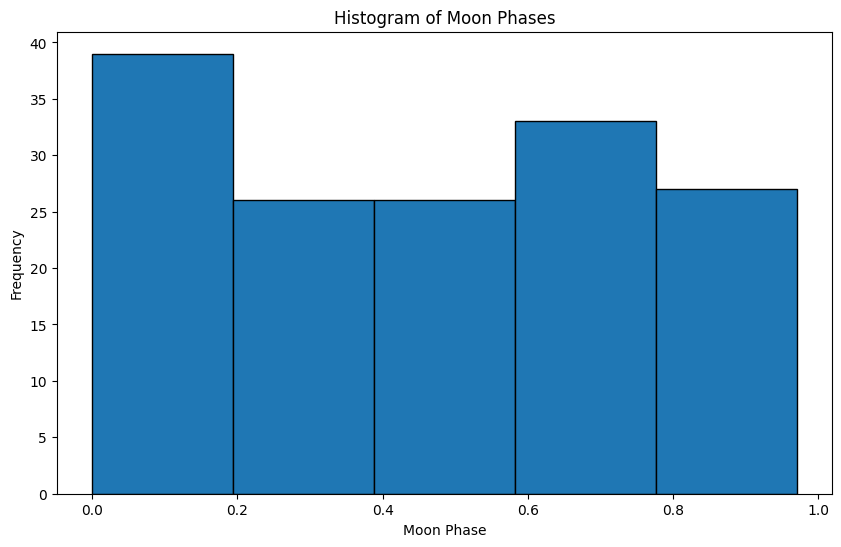

In [138]:
plt.figure(figsize=(10, 6))
plt.hist(df['Moon phase'], bins=5, edgecolor='black')
plt.xlabel('Moon Phase')
plt.ylabel('Frequency')
plt.title('Histogram of Moon Phases')
plt.show()

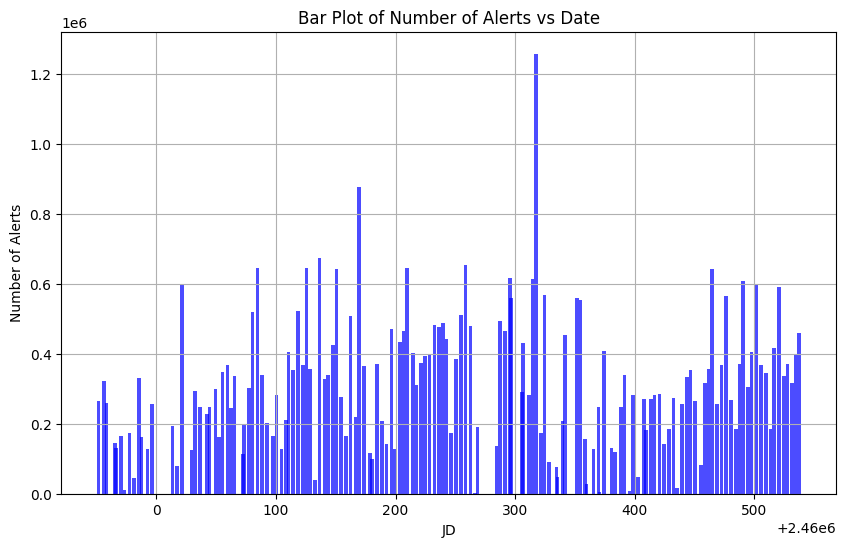

In [132]:
plt.figure(figsize=(10, 6))
plt.bar(df['jd'], df['Number of alerts'], color='blue', alpha=0.7, width=3)
plt.xlabel('JD')
plt.ylabel('Number of Alerts')
plt.title('Bar Plot of Number of Alerts vs Date')
plt.grid(True)
plt.show()

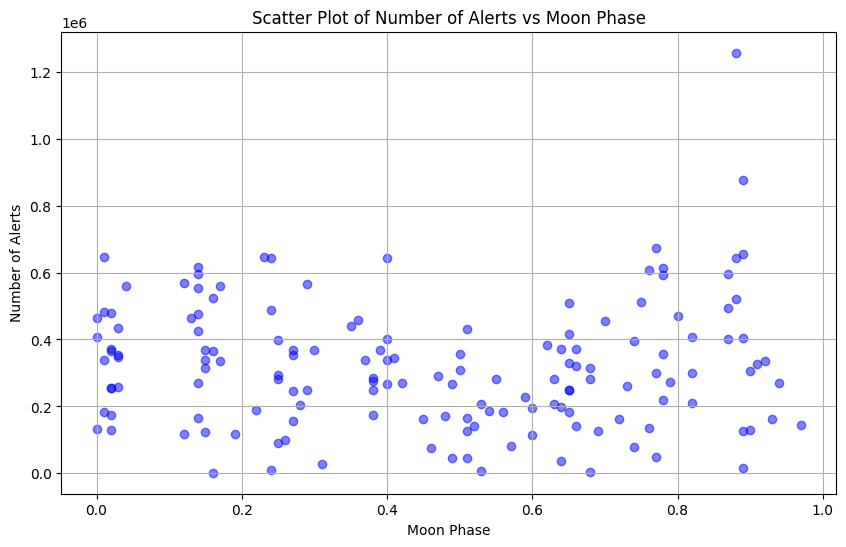

In [133]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Moon phase'], df['Number of alerts'], c='blue', alpha=0.5)
plt.xlabel('Moon Phase')
plt.ylabel('Number of Alerts')
plt.title('Scatter Plot of Number of Alerts vs Moon Phase')
plt.grid(True)
plt.show()